In [1]:
import abc
import numpy as np
import pandas as pd
from numpy import linalg
from typing import List
import time

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import mean_squared_error

# Реализация 

## Базовые Loss функии

In [2]:
class BaseLoss(abc.ABC):
    @abc.abstractmethod
    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Инструкция(чуть позже)
        """
        return NotImplementedError

    @abc.abstractmethod
    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Инструкция(чуть позже)
        """
        return NotImplementedError

### MSE - mean squared error

#### Classic


$Q(X, y, w) = \frac{1}{\ell} \lVert  Xw - y \rVert_2 ^ 2$

$\nabla_w Q(X, y, w) = \frac{2}{\ell} X^T(Xw - y)$

In [3]:
class MSELoss(BaseLoss):
    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        n = y.shape[0]
        L = X @ w - y
        
        Q = linalg.norm(L) ** 2 / n
        return Q

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        n = y.shape[0]
        L = X @ w - y

        Grad = 2 * X.T @ L / n
        return Grad

#### L1 - Lasso


$Q(X, y, w) = \frac{1}{\ell} \lVert  Xw - y \rVert ^ 2 + \lambda \lVert w \rVert_1$

$\nabla_w Q(X, y, w) = \frac{2}{\ell} X^T(Xw - y) + \lambda \cdot \text{sgn}(\hat{w})$

In [4]:
class MSEL1Loss(BaseLoss):
    def __init__(self, coef: float = 1.):
        self.coef = coef

    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        n = y.shape[0]
        L = X @ w - y
        
        MSE = linalg.norm(L) ** 2 / n
        L1 = self.coef * np.sum(np.abs(w[1:]))
        Q = MSE + L1
        
        return Q

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        n = y.shape[0]
        L = X @ w - y

        Grad_MSE = 2 * X.T @ L / n
        Grad_L1 = self.coef * np.sign(w)
        Grad_L1[0] = 0
        Grad = Grad_MSE + Grad_L1
        
        return Grad

#### L2 - Ridge

$Q(X, y, w) = \frac{1}{\ell} \lVert  Xw - y \rVert_2 ^ 2 + \lambda \lVert w \rVert_2^2$

$\nabla_w Q(X, y, w) = \frac{2}{\ell} X^T(Xw - y) + 2 \lambda w$

In [5]:
class MSEL2Loss(BaseLoss):
    def __init__(self, coef: float = 1.):
        self.coef = coef

    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        n = y.shape[0]
        L = X @ w - y
        
        MSE = linalg.norm(L) ** 2 / n
        L2 = self.coef * linalg.norm(w[1:]) ** 2
        Q = MSE + L2

        return Q

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        n = y.shape[0]
        L = X @ w - y

        Grad_MSE = 2 * X.T @ L / n
        Grad_L2 = 2 * self.coef * w
        Grad_L2[0] = 0
        Grad = Grad_MSE + Grad_L2

        return Grad

## Градиентные спуски

### Classic Gradient Descent

$w^{(k)} = w^{(k-1)} - \eta \nabla_w Q(w^{(k-1)})$

In [6]:
def gradient_descent(w_init: np.ndarray, X: np.ndarray, y: np.ndarray,
                     loss: BaseLoss, lr: float = 0.01, decay: float=  0., power: float = 1.0, n_iterations: int = 100000,
                     tol: float = 1e-8) -> (List[np.ndarray], List[float]):
    W = [w_init]
    L = [loss.calc_loss(X, y, w_init)]
    
    for i in range(n_iterations):
        lr_i =  lr / (1 + decay * i) ** power
        w_init_new = w_init - lr_i * loss.calc_grad(X, y, w_init)
        
        W.append(w_init_new)
        L.append(loss.calc_loss(X, y, w_init_new))
        if linalg.norm(w_init - w_init_new) < tol:
            break
        w_init = w_init_new

    return W, L
    

### Stochactic Gradient Descent

Пусть $$i \sim U\{1, \dots, m\}$$ $$w^{(k)} = w^{(k-1)} - \eta \sum\limits_{j=1}^n \nabla_w q_j(w^{(k-1)}),$$ где $q_i$ - градиент на $i$ элементе

`stochactic_gradient_descent` если не подать параметр batch_size то он поумолчанию 1, ну а так будет mini_batch версия

In [7]:
def stochactic_gradient_descent(w_init: np.ndarray, X: np.ndarray, y: np.ndarray,
                                loss: BaseLoss, lr: float = 0.01, decay: float = 0.0, 
                                power: float = 1.0, batch_size: int = 1, n_iteration = 100000) -> (List[np.ndarray], List[float]):
    W = [w_init]
    L = [loss.calc_loss(X, y, w_init)]
    for i in range(n_iteration):
        lr_i =  lr / (1 + decay * i) ** power
        index = np.random.choice(X.shape[0], size=batch_size)
        X_batch = X[index]
        y_batch = y[index]
    
        w_init_new = w_init - lr_i * loss.calc_grad(X_batch, y_batch, w_init)
        W.append(w_init_new)
        L.append(loss.calc_loss(X_batch, y_batch, w_init_new))
        w_init = w_init_new
        
    return W, L

## Линейная регрессия

In [8]:
class LinearRegressionCGD:
    def __init__(self, loss: BaseLoss, lr: float = 0.01, decay: float =  0.0,
                 power: float = 1.0, n_iterations: int = 10000, tol: float = 1e-8) -> None:
        self.loss = loss
        self.lr = lr
        self.decay = decay
        self.power = power
        self.n_iterations = n_iterations
        self.tol = tol
        
        self.w = None
        self.history_w = None
        self.history_l = None

    def fit(self, X: np.ndarray, y: np.ndarray) -> 'LinearRegressionCGD':

        # add intercept term
        X = np.hstack([np.ones([X.shape[0], 1]), X])
        
        # initialization weight
        w_start = np.random.normal(size=X.shape[-1])

        self.history_w, self.history_l = gradient_descent(
            w_init = w_start,
            X = X,
            y = y,
            loss = self.loss,
            lr = self.lr,
            decay = self.decay,
            power = self.power,
            n_iterations = self.n_iterations,
            tol = self.tol
        )

        self.w = self.history_w[-1]

        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        assert self.w is not None, "Модель ещё не была обучена! Используйте model.fit()"
        
        X = np.hstack([np.ones([X.shape[0], 1]), X])
        y = np.dot(X, self.w)
        
        return y

In [9]:
class LinearRegressionSGD:
    def __init__(self, loss: BaseLoss, lr: float = 0.01, decay: float = 0.0, 
                 power: float = 1.0, batch_size: int = 1, n_iteration: int = 10000) -> None:
        self.loss = loss
        self.lr = lr
        self.decay = decay
        self.power = power
        self.batch_size = batch_size
        self.n_iteration = n_iteration

        self.w = None
        self.history_w = None
        self.history_l = None

    def fit(self, X: np.ndarray, y: np.ndarray) -> 'LinearRegressionSGD':
        
        # add intercept term
        X = np.hstack([np.ones([X.shape[0], 1]), X])

        # initialization weight
        w_start = np.random.normal(size=X.shape[-1])

        self.history_w, self.history_l = stochactic_gradient_descent(
            w_init = w_start,
            X = X,
            y = y,
            loss = self.loss,
            lr = self.lr,
            decay = self.decay,
            power = self.power,
            batch_size = self.batch_size,
            n_iteration = self.n_iteration
        )
        self.w = self.history_w[-1]
        
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        assert self.w is not None, "Модель ещё не была обучена! Используйте model.fit()"

        X = np.hstack([np.ones([X.shape[0], 1]), X])
        y = np.dot(X, self.w)
        
        return y

# Время тестов!

In [10]:
data = fetch_california_housing()

df = pd.DataFrame(data.data, columns=data.feature_names)

df['Price'] = data.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [11]:
df.shape

(20640, 9)

In [12]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


Проверим на пропуски

In [14]:
df.isna().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

<Figure size 800x800 with 0 Axes>

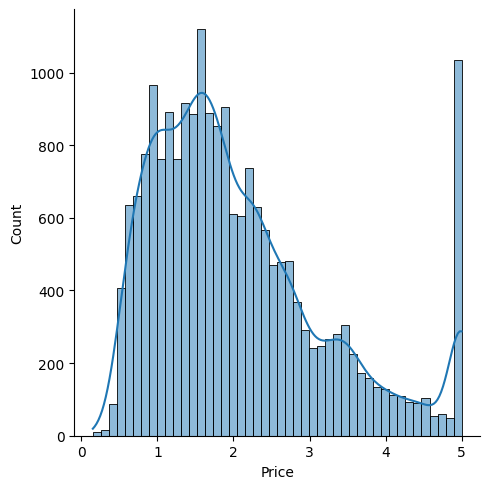

In [15]:
plt.figure(figsize = (8, 8))
sns.displot(df['Price'], kde=True)

Из графика видно что у нас распределение неравномерное + есть тяжелые хвосты. Попробуем прологорифмировать.

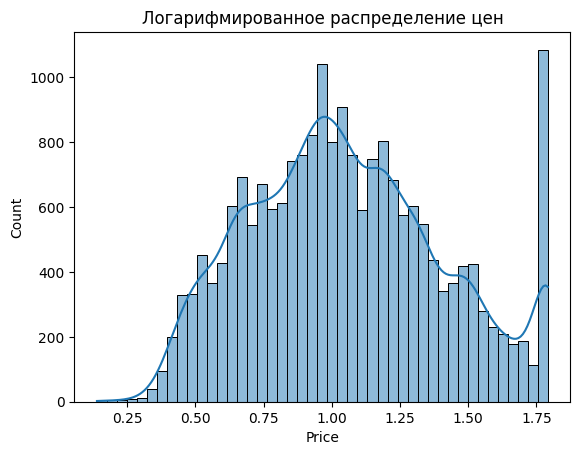

In [16]:
sns.histplot(np.log1p(df['Price']), kde=True)
plt.title("Логарифмированное распределение цен")
plt.show()

In [17]:
df['Price'] = np.log1p(df['Price'])

<Axes: >

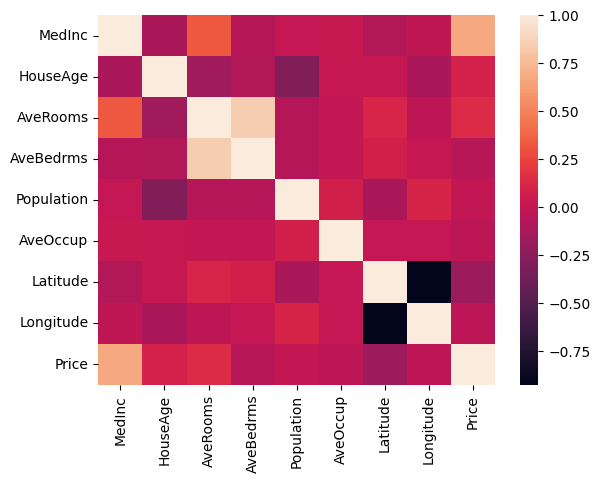

In [18]:
sns.heatmap(df.corr())

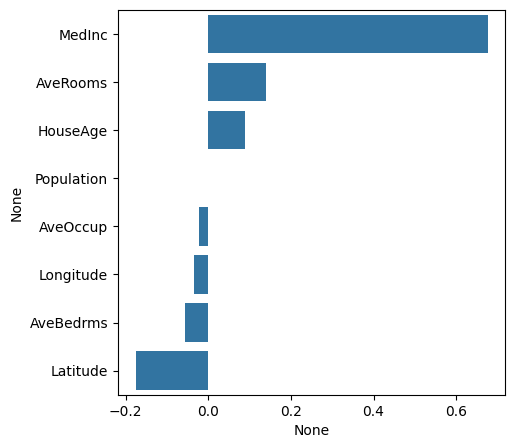

In [19]:
corr = df.drop('Price', axis=1).corrwith(df['Price']).sort_values(ascending=False)
plot = sns.barplot(y=corr.index, x=corr)
plot.figure.set_size_inches(5, 5)

Видно что `Population` вообще почти никак не коррелиурет с `Price` - это требудет доп исследования. 

Из тепловой карты видно, что `AveRooms` и `Avebedrms` имеют линейную зависимость, следовательно возьмём только `AveRooms`

In [20]:
df = df.drop('AveBedrms', axis = 1)

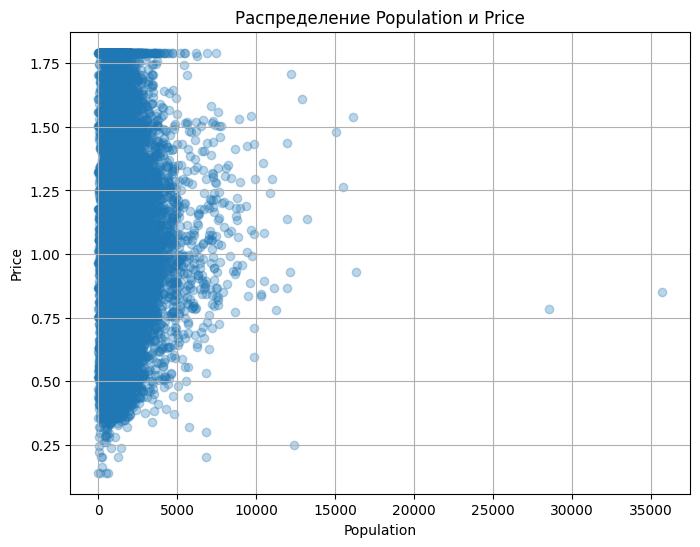

In [21]:
plt.figure(figsize=(8, 6))
plt.scatter(df['Population'], df['Price'], alpha=0.3)
plt.xlabel('Population')
plt.ylabel('Price')
plt.title('Распределение Population и Price')
plt.grid(True)
plt.show()

Видно, что у нас вообще нет никакой полезной информации, удалим его

In [22]:
df = df.drop('Population', axis=1)

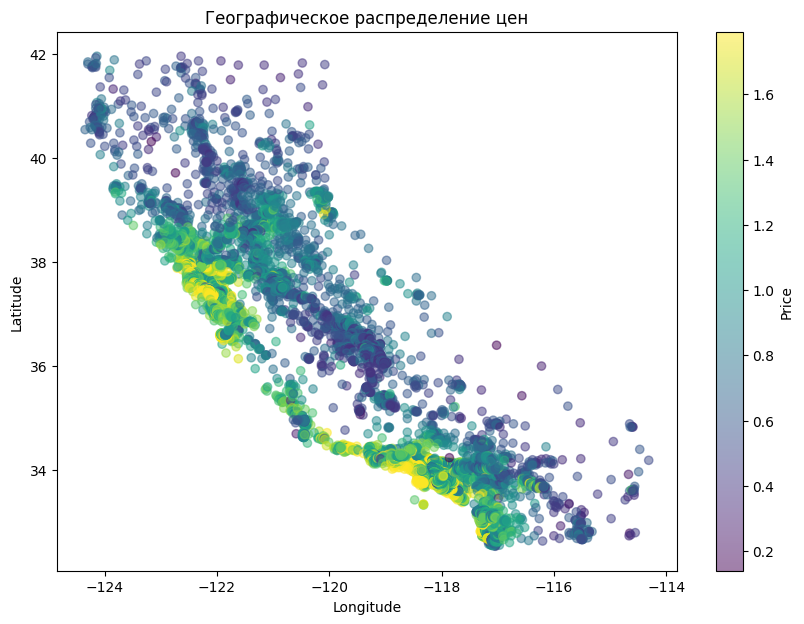

In [23]:
plt.figure(figsize=(10, 7))
plt.scatter('Longitude', 'Latitude', c='Price', data=df, cmap='viridis', alpha=0.5)
plt.colorbar(label='Price')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Географическое распределение цен')
plt.show()

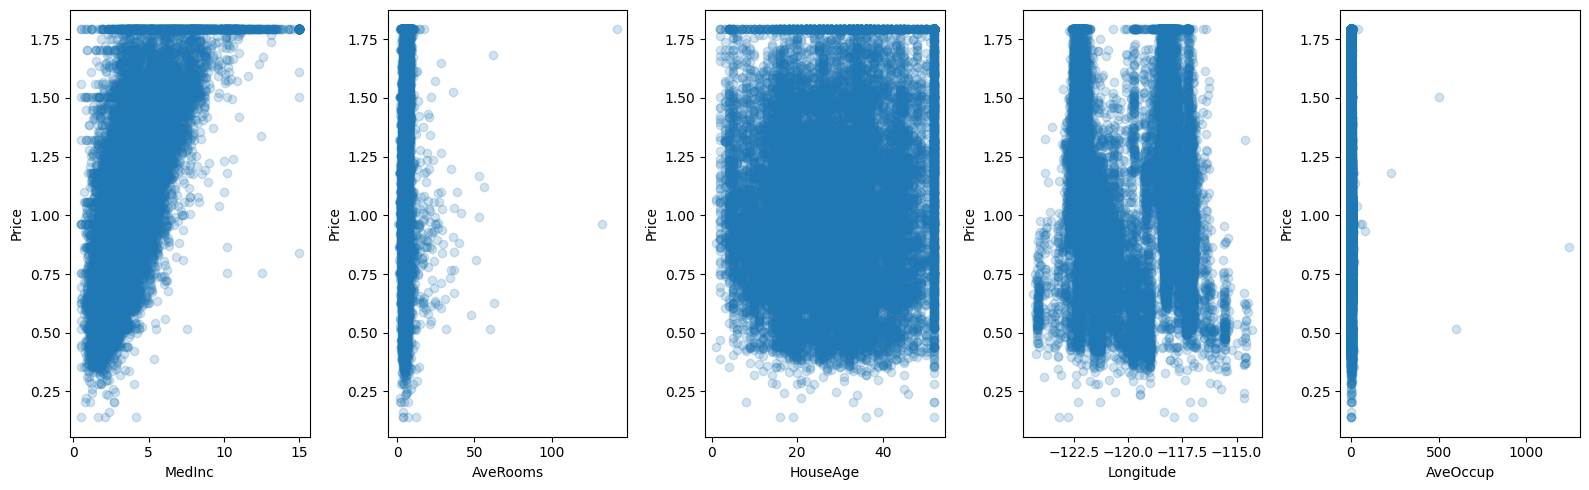

In [24]:
fig, axs = plt.subplots(figsize=(16, 5), ncols=5)
for i, feature in enumerate(['MedInc', "AveRooms", "HouseAge", "Longitude", "AveOccup"]):
    axs[i].scatter(df[feature], df['Price'], alpha=0.2)
    axs[i].set_xlabel(feature)
    axs[i].set_ylabel("Price")
plt.tight_layout()

Заметим что у `AveOccup` и `AveRooms` есть выбросы. Обрежем их

In [25]:
df = df[df['AveRooms'] < 50] 
df = df[df['AveOccup'] < 20]

А также заметим что `Longitude` не монотонна. Сделаем бинаризацию

In [26]:
X = df.drop('Price', axis=1)
y = df['Price']

In [27]:
kbd = KBinsDiscretizer(
    n_bins=10, 
    encode='onehot-dense', 
    strategy='quantile', 
    quantile_method='averaged_inverted_cdf'
)

lon_bins = kbd.fit_transform(X[['Longitude']])

bin_names = [f'Lon_Bin_{i}' for i in range(lon_bins.shape[1])]
lon_bins_df = pd.DataFrame(lon_bins, columns=bin_names, index=X.index) 

X = pd.concat([X.drop('Longitude', axis=1), lon_bins_df], axis=1)

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [29]:
model = LinearRegression()
st = time.time()
model.fit(X_train, y_train)
end = time.time()
print("MSE train :", mean_squared_error(model.predict(X_train), y_train))
print("MSE test :", mean_squared_error(model.predict(X_test), y_test))
print('Time: ', end - st)
print('\n')

model = LinearRegressionCGD(MSELoss())
st = time.time()
model.fit(X_train, y_train)
end = time.time()
print("MSE train :", mean_squared_error(model.predict(X_train), y_train))
print("MSE test :", mean_squared_error(model.predict(X_test), y_test))
print('Time: ', end - st)
print('\n')

model = LinearRegressionSGD(MSELoss(), lr=0.01)
st = time.time()
model.fit(X_train, y_train.values)
end = time.time()
print("MSE train :", mean_squared_error(model.predict(X_train), y_train.values))
print("MSE test :", mean_squared_error(model.predict(X_test), y_test.values))
print('Time: ', end - st)
print('\n')

MSE train : 0.040230009761288855
MSE test : 0.04108312592945721
Time:  0.0022039413452148438


MSE train : 0.040230009765336965
MSE test : 0.041083118661693445
Time:  1.4459409713745117


MSE train : 0.044062620802188805
MSE test : 0.0444582426707168
Time:  0.0822138786315918


